In [1]:
!git clone https://github.com/samarapires-ml/Buy-Now-Pay-Later--BNPL--Risk-Prediction.git

Cloning into 'Buy-Now-Pay-Later--BNPL--Risk-Prediction'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 63 (delta 25), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 5.77 MiB | 15.20 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [2]:
%cd Buy-Now-Pay-Later--BNPL--Risk-Prediction

/content/Buy-Now-Pay-Later--BNPL--Risk-Prediction


In [4]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [5]:
#load data
url = "https://raw.githubusercontent.com/samarapires-ml/Buy-Now-Pay-Later--BNPL--Risk-Prediction/main/data/processed/clean_full_data.csv"
df = pd.read_csv(url)

df.head()

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,Gender_Male,Gender_Non-Binary,Purchase_Category_Electronics,Purchase_Category_Fashion,Purchase_Category_Groceries,...,BNPL_Provider_Klarna,BNPL_Provider_Sezzle,Device_Type_Mobile,Device_Type_Tablet,Connection_Type_VPN,Connection_Type_WiFi,Browser_Edge,Browser_Firefox,Browser_Safari,target
0,1.110297,-1.303034,-1.388519,-0.445029,-0.199028,True,False,False,False,False,...,False,True,False,True,False,True,False,True,False,0
1,0.371122,0.096571,-1.382224,-0.531422,-0.632426,True,False,False,False,True,...,False,False,True,False,False,True,False,True,False,0
2,-0.663723,0.422711,0.355240,1.482538,-0.120229,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,0
3,1.405967,0.778516,-0.651985,-0.627730,1.514864,True,False,False,True,False,...,False,True,True,False,False,False,False,False,False,0
4,-1.181145,-1.311090,-0.450540,1.821031,-1.065824,True,False,False,False,False,...,True,False,True,False,False,False,False,False,False,1


In [6]:
df.shape

(50000, 23)

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer_Age                        50000 non-null  float64
 1   Annual_Income                       50000 non-null  float64
 2   Credit_Score                        50000 non-null  float64
 3   Purchase_Amount                     50000 non-null  float64
 4   Checkout_Time_Seconds               50000 non-null  float64
 5   Gender_Male                         50000 non-null  bool   
 6   Gender_Non-Binary                   50000 non-null  bool   
 7   Purchase_Category_Electronics       50000 non-null  bool   
 8   Purchase_Category_Fashion           50000 non-null  bool   
 9   Purchase_Category_Groceries         50000 non-null  bool   
 10  Purchase_Category_Home & Furniture  50000 non-null  bool   
 11  Purchase_Category_Travel            50000

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,target
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000
mean,2.028777e-16,1.544365e-16,7.993606e-18,-4.760636e-17,1.099920e-16,0.232020
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,0.422126
min,-1.698568e+00,-1.728057e+00,-1.722163e+00,-7.693584e-01,-1.715921e+00,0.000000
25%,-8.854753e-01,-8.666192e-01,-8.723160e-01,-6.220645e-01,-8.688252e-01,0.000000
50%,1.534527e-03,3.133814e-03,-9.878996e-03,-4.733543e-01,-2.029091e-03,0.000000
75%,8.885444e-01,8.740883e-01,8.651484e-01,3.141014e-01,8.647670e-01,0.000000
max,1.701637e+00,1.729311e+00,1.733881e+00,3.449761e+00,1.711863e+00,1.000000


In [8]:
df.columns

Index(['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount',
       'Checkout_Time_Seconds', 'Gender_Male', 'Gender_Non-Binary',
       'Purchase_Category_Electronics', 'Purchase_Category_Fashion',
       'Purchase_Category_Groceries', 'Purchase_Category_Home & Furniture',
       'Purchase_Category_Travel', 'BNPL_Provider_Afterpay',
       'BNPL_Provider_Klarna', 'BNPL_Provider_Sezzle', 'Device_Type_Mobile',
       'Device_Type_Tablet', 'Connection_Type_VPN', 'Connection_Type_WiFi',
       'Browser_Edge', 'Browser_Firefox', 'Browser_Safari', 'target'],
      dtype='object')

In [9]:
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.76798
1,0.23202


In [10]:
#Feature Engineering
# Financial stress feature
df['purchase_income_ratio'] = df['Purchase_Amount'] / (df['Annual_Income'] + 1e-5)

# Credit-adjusted spending
df['purchase_credit_ratio'] = df['Purchase_Amount'] / (df['Credit_Score'] + 1e-5)

# Behavioral feature (standardized data: <0 = faster than average)
df['fast_checkout'] = (df['Checkout_Time_Seconds'] < 0).astype(int)

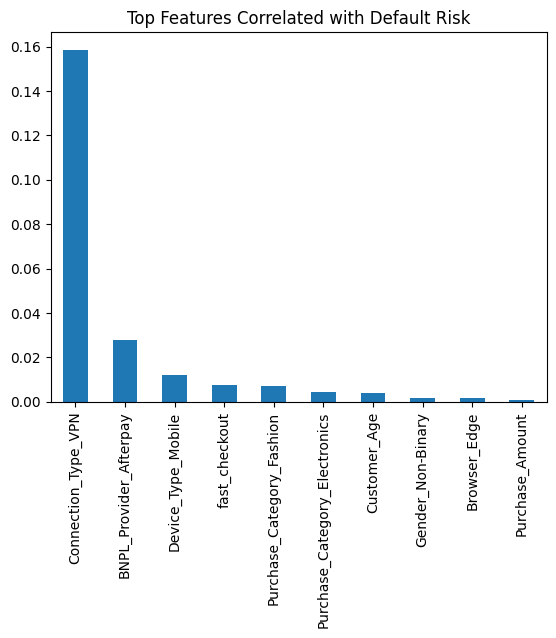

In [11]:
#correlation with target
corr_target = df.corr()['target'].sort_values(ascending=False)

plt.figure()
corr_target.drop('target').head(10).plot(kind='bar')
plt.title("Top Features Correlated with Default Risk")
plt.show()

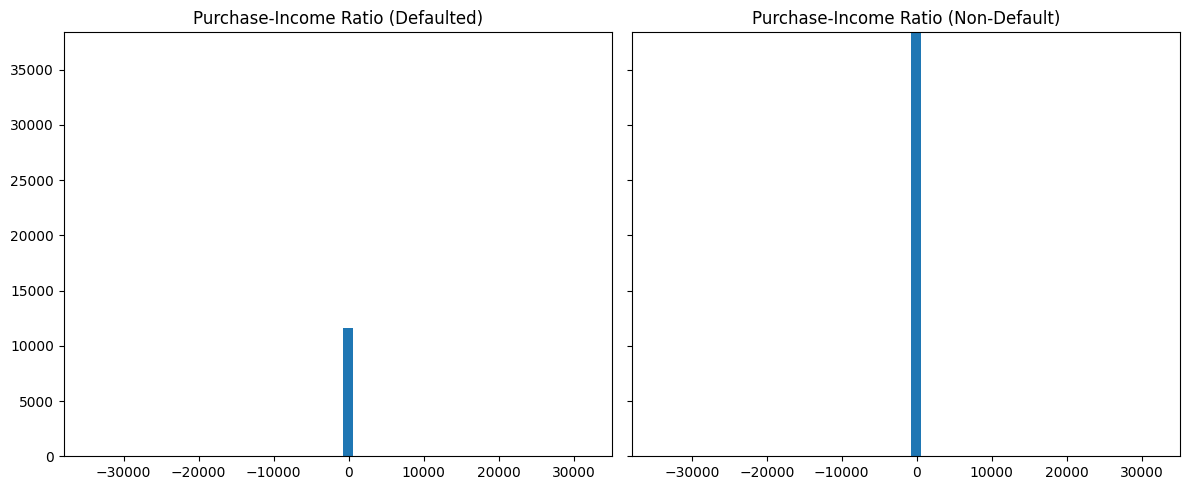

In [12]:
#Engineered Feature Selection
# Common bins
bins = np.linspace(df['purchase_income_ratio'].min(),
                   df['purchase_income_ratio'].max(),
                   50)

# Compute max y-value across both groups
y1, _ = np.histogram(df[df['target'] == 1]['purchase_income_ratio'], bins=bins)
y2, _ = np.histogram(df[df['target'] == 0]['purchase_income_ratio'], bins=bins)
ymax = max(y1.max(), y2.max())

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

axes[0].hist(df[df['target'] == 1]['purchase_income_ratio'], bins=bins)
axes[0].set_title("Purchase-Income Ratio (Defaulted)")
axes[0].set_ylim(0, ymax)

axes[1].hist(df[df['target'] == 0]['purchase_income_ratio'], bins=bins)
axes[1].set_title("Purchase-Income Ratio (Non-Default)")
axes[1].set_ylim(0, ymax)

plt.tight_layout()
plt.show()

In [13]:
#Feature Selection
selected_features = [
    'Annual_Income',
    'Credit_Score',
    'Purchase_Amount',
    'Checkout_Time_Seconds',
    'Customer_Age',
    'purchase_income_ratio',
    'purchase_credit_ratio',
    'fast_checkout'
]

categorical_cols = [col for col in df.columns if '_' in col and col != 'target']

X = df[selected_features + categorical_cols]
y = df['target']

In [14]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [18]:
!mv /content/Buy-Now-Pay-Later--BNPL--Risk-Prediction/X_train.csv data/processed/
!mv /content/Buy-Now-Pay-Later--BNPL--Risk-Prediction/X_test.csv data/processed/
!mv /content/Buy-Now-Pay-Later--BNPL--Risk-Prediction/y_train.csv data/processed/
!mv /content/Buy-Now-Pay-Later--BNPL--Risk-Prediction/y_test.csv data/processed/

In [17]:
!ls /content

Buy-Now-Pay-Later--BNPL--Risk-Prediction  sample_data


In [19]:
!git add data/processed/X_train.csv
!git add data/processed/X_test.csv
!git add data/processed/y_train.csv
!git add data/processed/y_test.csv

!git commit -m "Add preprocessed train/test split files"

[main 40bb6d7] Add preprocessed train/test split files
 4 files changed, 100004 insertions(+)
 create mode 100644 data/processed/X_test.csv
 create mode 100644 data/processed/X_train.csv
 create mode 100644 data/processed/y_test.csv
 create mode 100644 data/processed/y_train.csv
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 3.57 MiB | 3.20 MiB/s, done.
Total 8 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/samarapires-ml/Buy-Now-Pay-Later--BNPL--Risk-Prediction.git
   a72da24..40bb6d7  main -> main
